# Phase 1.2 — Dubins `slack_weight` sweep & comparison (test-only)

This notebook is a **test / comparison** tool. It sweeps `slack_weight` (the loop lives
here, in the notebook), calling the single-setting solver `solve_dubins_slack.m` **once per
weight**, and compares across weights:

1. the per-sample **slack distributions**, and
2. the **corrected reach-avoid region** — the certified funnel
   $\{\,\bm y\in\mathcal X_S\setminus\mathcal X_T:\ \mathrm{cert}(\bm y)-\delta/\lambda\ge 0\,\}$
   (cert $=\psi$, the safe-set barrier the SOP certifies; this is the **corrected** definition,
   accounting for the descent slack $\delta$).

For each weight it also records the candidate setting $u_{\max}^{\rm eff}$ and the **kept sample
subset**. It does **not** pick a single weight or write `phase1_2_outputs` — a later script
_manually_ selects a weight from these results ($u_{\max}^{\rm eff}$ + kept samples) for the
constrained-$k_1$ synthesis. Purpose: decide _which_ `slack_weight` (→ bound + samples) is
appropriate for the downstream controller.

Self-contained: MATLAB on `revision/matlab_frozen` + `revision/slack_diagnostic`; the box is
Phase 1.1 `X_S_eff`; all I/O under `revision/data/`.


## §0 — Per-sample slack SOP (what `solve_dubins_slack.m` solves)

Backstepping gives an output-feedback reach-avoid controller $u(\bm x)=A(\bm x)^{-1}b(\bm x;k_1)$
parameterized by $k_1(\bm y)$. The **per-sample slack** SOP probes a requested bound $\mathrm{ub}$
and reports, per state, how far the controller must exceed it. Over $N$ valid reach-avoid samples
$\{\bm x_j\}$ and channels $i$:

$$
\min_{k_1,\,\delta\ge0,\,s_{j,i}\ge0}\ \delta + w\sum_{j,i}s_{j,i}
\quad\text{s.t.}\quad |u_i(\bm x_j)|\le \mathrm{ub}_i+s_{j,i},
$$

$$
\underbrace{\nabla\psi\cdot k_1-\lambda\psi+\delta-s_1\psi-s_2\,\text{target}\in\Sigma[\bm y]}_{\text{reach-avoid descent (hard, SOS)}},\qquad
\underbrace{M(\bm x_j)\succeq0}_{\text{certificate (hard, per sample)}}.
$$

`slack_weight` $=w$ trades the descent slack $\delta$ against the input-bound slacks $s_{j,i}$.
The **certified reach-avoid set** is the corrected funnel $\{\mathrm{cert}-\delta/\lambda\ge0\}$
(it is empty once $\delta/\lambda>\max\mathrm{cert}$) — which is why $w$ matters and why we sweep it.


## §1 — Parameters, MATLAB trigger, and the corrected reach-avoid certificate

`PARAMS` is the single source of truth (pushed to `solve_dubins_slack.m` via ENV per weight).
`SWEEP_WEIGHTS` is the list the notebook loops over. We also build the output-space certificate
`cert` $=\psi$ and a dense $\mathcal X_S\setminus\mathcal X_T$ sample, used for the corrected
funnel size.


In [15]:
import json
import os
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp

# locate repo ROOT via revision/matlab_frozen (no reference to the main repo)
ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "revision", "matlab_frozen")):
        break
    ROOT = os.path.dirname(ROOT)
REV = os.path.join(ROOT, "revision")
FROZEN = os.path.join(REV, "matlab_frozen")
SLACK_DIR = os.path.join(REV, "slack_diagnostic")
REV_DATA = os.path.join(REV, "data")
os.makedirs(REV_DATA, exist_ok=True)
MATLAB_BIN = shutil.which("matlab") or "/usr/local/bin/matlab"

# ============================ ALL PARAMETERS =============================
# Single source of truth; solve_dubins_slack.m sets no parameter values (reads ENV).
PARAMS = {
    "mu": 0.1,  # backstepping certificate parameter (paper baseline)
    "xi0": 1e-8,  # SOS floor lambda >= xi0 for the vanilla k1 (descent rate)
    "ub": 5.0,  # requested (tight) input bound to probe; |u_i| <= ub + slack
    "n_valid_samples": 250,  # number of valid reach-avoid SOP samples
    "ds": 4,  # SOS auxiliary degree
    "dv": 4,  # k1 polynomial degree
    "seed": 42,  # RNG seed for the reach-avoid sampler (fixed -> same samples per weight)
    "coverage_pct": 80,  # per-weight kept subset: lowest-q% by per-channel slack
}
# slack_weight is NOT a single value here -- it is swept:
SWEEP_WEIGHTS = [0.1, 1e-2, 1e-3, 1e-5]

# ENV pushed to MATLAB (per-weight SLACK_WEIGHT is added inside the loop).
ENV = {
    "MU": PARAMS["mu"],
    "XI0": PARAMS["xi0"],
    "UB": PARAMS["ub"],
    "N_VALID": PARAMS["n_valid_samples"],
    "DS": PARAMS["ds"],
    "DV": PARAMS["dv"],
    "SEED": PARAMS["seed"],
}


def run_matlab(script_name, env_overrides):
    """Run a revision MATLAB driver (revision dirs only on path); print key lines."""
    env = os.environ.copy()
    env.update({k: str(v) for k, v in env_overrides.items()})
    cmd = [
        MATLAB_BIN,
        "-batch",
        f"addpath('{FROZEN}'); addpath('{SLACK_DIR}'); "
        f"try, {script_name}; catch e, fprintf(2,'%s\\n',e.message); exit(1); end; exit(0);",
    ]
    t0 = time.time()
    proc = subprocess.Popen(
        cmd,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    lines, KEY = [], (
        "solve_dubins_slack",
        "valid",
        "wrote",
        "Added",
        "channel",
        "achievable",
        "rror",
        "X_S_eff",
        "box",
    )
    for raw in proc.stdout:
        line = raw.rstrip()
        lines.append(line)
        if any(k in line for k in KEY):
            print(f"[matlab +{time.time() - t0:5.0f}s] {line}")
            sys.stdout.flush()
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(
            f"MATLAB {script_name} failed (rc={proc.returncode}); last lines:\n"
            + "\n".join(lines[-15:])
        )
    return "\n".join(lines)


# ---- corrected reach-avoid certificate cert == psi in OUTPUT coords (mirror solve_dubins_slack.m)
y1s, y2s = sp.symbols("y1 y2")
h_raw_s = -(y1s**4 + y2s**4 - 16) * (y1s**4 + y2s**4 - 4)
target_ys = (y2s) ** 2 + ((y1s + 1.7) / 0.5) ** 2 - 0.4
cert_ys = (
    1e-3 * (-target_ys + 300) * h_raw_s
)  # cert == psi == safe-set barrier == reach-avoid certificate
cert_fn = sp.lambdify((y1s, y2s), cert_ys, "numpy")
targ_fn = sp.lambdify((y1s, y2s), target_ys, "numpy")

# dense sample of X_S\X_T (cert >= 0 AND outside target) -> corrected funnel { cert - delta/lambda >= 0 }
N_DENSE, LO, HI = 1_000_000, -2.2, 2.2
_rng = np.random.default_rng(0)
_Yd = _rng.uniform(LO, HI, size=(2, N_DENSE))
_cv = np.asarray(cert_fn(_Yd[0], _Yd[1]), float)
_tv = np.asarray(targ_fn(_Yd[0], _Yd[1]), float)
_in = (_cv >= 0) & (_tv > 0)
Yin = _Yd[:, _in]
cert_in = _cv[_in]
cert_max = float(cert_in.max())
gg = np.linspace(LO, HI, 400)
G1, G2 = np.meshgrid(gg, gg)
Zc = np.asarray(cert_fn(G1, G2), float)
Zt = np.asarray(targ_fn(G1, G2), float)

print("ROOT:", ROOT, "| MATLAB:", MATLAB_BIN, "exists:", os.path.exists(MATLAB_BIN))
print("PARAMS:", PARAMS)
print("SWEEP_WEIGHTS:", SWEEP_WEIGHTS)
print(
    f"dense X_S\\X_T: {cert_in.size:,}/{N_DENSE:,}; cert range [{cert_in.min():.3g}, {cert_max:.3g}]"
)
print(
    f"=> corrected funnel {{cert - delta/lambda >= 0}} is EMPTY when delta/lambda > max cert = {cert_max:.3g}"
)

ROOT: /home/jianqiang/Downloads/reach_avoid_backstepping_MPC | MATLAB: /usr/local/bin/matlab exists: True
PARAMS: {'mu': 0.1, 'xi0': 1e-08, 'ub': 5.0, 'n_valid_samples': 250, 'ds': 4, 'dv': 4, 'seed': 42, 'coverage_pct': 80}
SWEEP_WEIGHTS: [0.1, 0.01, 0.001, 1e-05]
dense X_S\X_T: 351,279/1,000,000; cert range [1.87e-05, 10.8]
=> corrected funnel {cert - delta/lambda >= 0} is EMPTY when delta/lambda > max cert = 10.8


## §2 — Sweep loop (notebook drives `solve_dubins_slack` per weight) + save all results

For each `slack_weight` the notebook runs the **unchanged** single-setting solver
`solve_dubins_slack.m` (which overwrites `slack_persample/meta_dubins.csv`), then reads it and
computes, **for that weight**: the candidate $u_{\max}^{\rm eff}$ (per-channel, $=\mathrm{ub}+$
ceil-to-0.1 of the `coverage_pct`-th slack), the kept sample subset, and the corrected funnel
size $\{\mathrm{cert}-\delta/\lambda\ge0\}$. All weights are saved to
`sweep_summary_dubins.csv`, `slack_persample_byweight_dubins.csv`, `kept_byweight_dubins.csv`.
(Samples are identical across weights — seed fixed — so the distributions are directly comparable.)


In [16]:
SWEEP_REGENERATE = False  # True -> wipe ALL sweep outputs and recompute every weight
RETRIES = 2  # extra attempts per weight on a MATLAB crash (rc<0; e.g. "malloc unaligned tcache")
SUMMARY_CSV = os.path.join(REV_DATA, "sweep_summary_dubins.csv")
PSBW_CSV = os.path.join(REV_DATA, "slack_persample_byweight_dubins.csv")
KEPTBW_CSV = os.path.join(REV_DATA, "kept_byweight_dubins.csv")
SIG_PATH = os.path.join(REV_DATA, "sweep_sig_dubins.json")


def ceil_1dp(x):
    return float(np.ceil(round(x * 10.0, 6)) / 10.0)


# ---- RESUME cache: weights are computed ONE BY ONE; a weight already saved is
# SKIPPED (not recomputed). A weight is (re)run only if it is missing -- new, or
# it previously failed. The cache is invalidated (full redo) only if the
# non-weight PARAMS change or SWEEP_REGENERATE=True.
SIG = {
    k: float(PARAMS[k])
    for k in ("mu", "xi0", "ub", "n_valid_samples", "ds", "dv", "seed", "coverage_pct")
}


def _sig_match():
    if not os.path.exists(SIG_PATH):
        return False
    try:
        old = json.load(open(SIG_PATH))
    except Exception:
        return False
    return set(old) == set(SIG) and all(
        abs(float(old[k]) - float(SIG[k])) <= 1e-12 + 1e-9 * abs(float(SIG[k]))
        for k in SIG
    )


resume = (not SWEEP_REGENERATE) and os.path.exists(SUMMARY_CSV) and _sig_match()
if not resume:
    for f in (SUMMARY_CSV, PSBW_CSV, KEPTBW_CSV):
        if os.path.exists(f):
            os.remove(f)
    print("(no reusable cache -> computing all SWEEP_WEIGHTS fresh)")

prev_sum = (
    pd.read_csv(SUMMARY_CSV) if (resume and os.path.exists(SUMMARY_CSV)) else None
)
prev_ps = pd.read_csv(PSBW_CSV) if (resume and os.path.exists(PSBW_CSV)) else None
prev_kept = pd.read_csv(KEPTBW_CSV) if (resume and os.path.exists(KEPTBW_CSV)) else None
done_w = (
    set(np.round(prev_sum["slack_weight"].values, 12))
    if prev_sum is not None
    else set()
)


def _cat(prev, new_list):
    parts = ([prev] if prev is not None and len(prev) else []) + [
        p for p in new_list if len(p)
    ]
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


new_rows, new_ps, new_kept, failed = [], [], [], []
for w in SWEEP_WEIGHTS:
    if round(w, 12) in done_w:
        print(f"=== slack_weight = {w:g}  (cached -> skip) ===")
        continue
    print(f"\n=== slack_weight = {w:g} ===")
    dfw = mw = None
    for attempt in range(1 + RETRIES):
        try:
            run_matlab("solve_dubins_slack", {**ENV, "SLACK_WEIGHT": w})
            dfw = pd.read_csv(os.path.join(REV_DATA, "slack_persample_dubins.csv"))
            mw = pd.read_csv(os.path.join(REV_DATA, "slack_meta_dubins.csv")).iloc[0]
            break
        except Exception as e:
            print(
                f"  [attempt {attempt + 1}/{1 + RETRIES}] FAILED: {str(e).splitlines()[0]}"
            )
            dfw = None
    if dfw is None:
        print(
            f"  [SKIP] slack_weight={w:g} failed after {1 + RETRIES} attempts; continuing."
        )
        failed.append(w)
        continue
    lam, dlt = float(mw["lambda"]), float(mw["delta"])
    ub = float(mw["ub_req"])
    s_thr_om = ceil_1dp(np.percentile(dfw["slack1"].values, PARAMS["coverage_pct"]))
    s_thr_a = ceil_1dp(np.percentile(dfw["slack2"].values, PARAMS["coverage_pct"]))
    umax_om, umax_a = round(ub + s_thr_om, 1), round(ub + s_thr_a, 1)
    keep = (dfw["slack1"] <= s_thr_om) & (dfw["slack2"] <= s_thr_a)
    funnel_pct = 100.0 * float(np.mean((cert_in - dlt / lam) >= 0))
    new_rows.append(
        dict(
            slack_weight=w,
            lam=lam,
            delta=dlt,
            delta_over_lambda=dlt / lam,
            u_max_eff_omega=umax_om,
            u_max_eff_a=umax_a,
            n_kept=int(keep.sum()),
            n_total=int(len(dfw)),
            funnel_pct=funnel_pct,
        )
    )
    d = dfw.copy()
    d.insert(0, "slack_weight", w)
    new_ps.append(d)
    k = dfw[keep].copy()
    k.insert(0, "slack_weight", w)
    new_kept.append(k)
    print(
        f"  lambda={lam:.4g} delta={dlt:.4g} delta/lambda={dlt/lam:.4g}; "
        f"kept={int(keep.sum())}/{len(dfw)}; corrected funnel={funnel_pct:.1f}%"
    )
    # incremental save (cache + this run so far) so a later crash keeps progress
    _cat(prev_sum, [pd.DataFrame(new_rows)]).to_csv(SUMMARY_CSV, index=False)
    _cat(prev_ps, new_ps).to_csv(PSBW_CSV, index=False)
    _cat(prev_kept, new_kept).to_csv(KEPTBW_CSV, index=False)
    json.dump(SIG, open(SIG_PATH, "w"))

if not os.path.exists(SUMMARY_CSV):
    raise RuntimeError("no results saved -- every weight failed? (check MATLAB/MOSEK).")
df_summary = pd.read_csv(SUMMARY_CSV)
df_summary = (
    df_summary[
        df_summary["slack_weight"].round(12).isin([round(w, 12) for w in SWEEP_WEIGHTS])
    ]
    .sort_values("slack_weight")
    .reset_index(drop=True)
)
print(
    f"\n[i] {len(done_w & {round(w, 12) for w in SWEEP_WEIGHTS})} weight(s) reused from cache, {len(new_rows)} newly computed"
    + (
        f"; FAILED this run: {[f'{w:g}' for w in failed]} (re-run to retry just these)"
        if failed
        else ""
    )
)
df_summary

(no reusable cache -> computing all SWEEP_WEIGHTS fresh)

=== slack_weight = 0.1 ===
[matlab +    3s] solve_dubins_slack: mu=0.1 xi0=1e-08 ub=5 n_valid=250 slack_weight=0.1
[matlab +    3s]   X_S_eff box (from phase1_1_outputs_dubins.json):
[matlab +    6s] sample_n_valid: collected 250 valid (target 250) in 1 iter, total tried 750, yield 33.3%
[matlab +   17s] Added PER-SAMPLE slack control-limit constraints.
[matlab +   44s] Added certificate LMI constraints (per-sample slack variant).
[matlab +  106s]   channel 1 slack:  max=33.74  mean=2.277  p50=0.000153  p90=7.887  p99=28.52  nz_frac=100.0%
[matlab +  106s]   channel 2 slack:  max=3.223  mean=0.1521  p50=0.000153  p90=0.04955  p99=2.832  nz_frac=100.0%
[matlab +  106s]   wrote /home/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/slack_persample_dubins.csv  (250 rows)
[matlab +  106s]   wrote /home/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/slack_meta_dubins.csv
[matlab +  106s] solve_dubins_sla

,slack_weight,lam,delta,delta_over_lambda,u_max_eff_omega,u_max_eff_a,n_kept,n_total,funnel_pct
0,0.00001,1.094563e-08,6.143029e-10,5.612311e-02,7.9,5.1,187,250,99.672340
1,0.00100,1.094563e-08,7.711305e-10,7.045099e-02,7.9,5.1,187,250,99.592631
2,0.01000,1.094563e-08,7.814196e-08,7.139100e+00,7.9,5.1,187,250,50.509993
3,0.10000,1.094563e-08,5.664291e-02,5.174933e+06,7.8,5.1,186,250,0.000000


## §3 — Slack distribution vs `slack_weight`

Per-channel slack CDFs overlaid across weights (same sample set, fixed seed). Shows how the
per-sample input-bound violation distribution shifts with `slack_weight` — and hence the
effective bound $u_{\max}^{\rm eff}=\mathrm{ub}+$ quantile each weight implies.


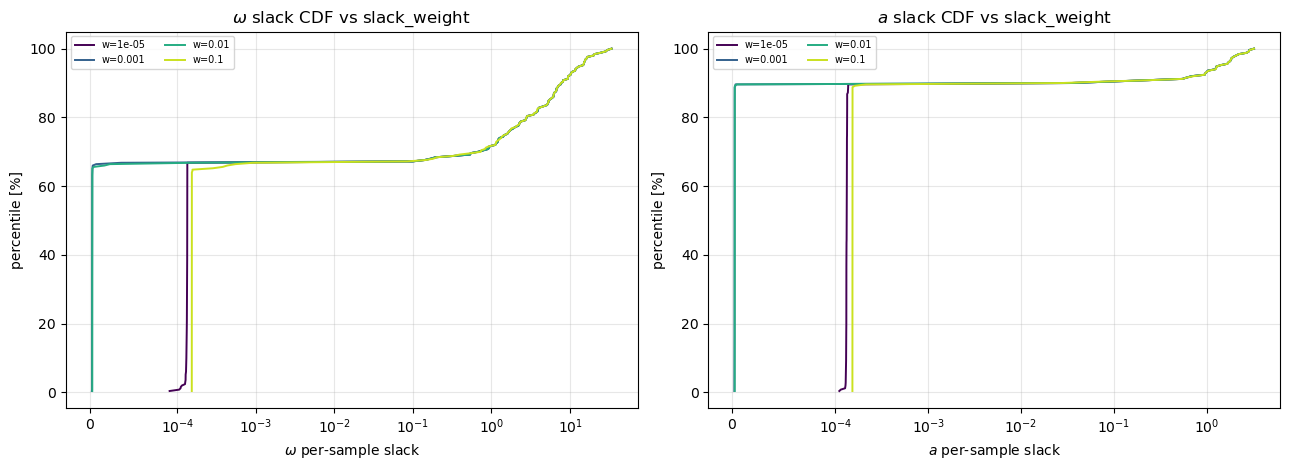

per-weight slack summary (max slack -> u_max_eff candidate):
 slack_weight  u_max_eff_omega  u_max_eff_a  n_kept  n_total
      0.00001              7.9          5.1     187      250
      0.00100              7.9          5.1     187      250
      0.01000              7.9          5.1     187      250
      0.10000              7.8          5.1     186      250


In [17]:
psbw = pd.read_csv(PSBW_CSV)
psbw = psbw[
    psbw["slack_weight"].round(12).isin([round(w, 12) for w in SWEEP_WEIGHTS])
]  # restrict to current SWEEP_WEIGHTS (cache may hold more)
weights = sorted(psbw["slack_weight"].unique())
cmap = plt.cm.viridis(np.linspace(0, 0.92, len(weights)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (col, lab) in zip(axes, [("slack1", r"$\omega$"), ("slack2", "$a$")]):
    for w, c in zip(weights, cmap):
        s = np.sort(psbw[psbw["slack_weight"] == w][col].values)
        ax.plot(
            s,
            100 * np.arange(1, s.size + 1) / s.size,
            lw=1.4,
            color=c,
            label=f"w={w:g}",
        )
    ax.set_xscale("symlog", linthresh=1e-4)
    ax.set_xlabel(f"{lab} per-sample slack")
    ax.set_ylabel("percentile [%]")
    ax.set_title(f"{lab} slack CDF vs slack_weight")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_dist_byweight_dubins.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

# summary: max slack + implied u_max_eff per weight
print("per-weight slack summary (max slack -> u_max_eff candidate):")
print(
    df_summary[
        ["slack_weight", "u_max_eff_omega", "u_max_eff_a", "n_kept", "n_total"]
    ].to_string(index=False)
)

## §4 — Corrected reach-avoid region (funnel) vs `slack_weight`

Dense $\mathcal X_S\setminus\mathcal X_T$ points coloured by membership in the **corrected**
funnel $\{\,\mathrm{cert}-\delta/\lambda\ge 0\,\}$ (blue), one panel per weight, plus the
`funnel%` and $\delta/\lambda$ curves. This — together with §3 — is what the later script uses
to pick `slack_weight`: a non-empty funnel **and** an acceptable $u_{\max}^{\rm eff}$.


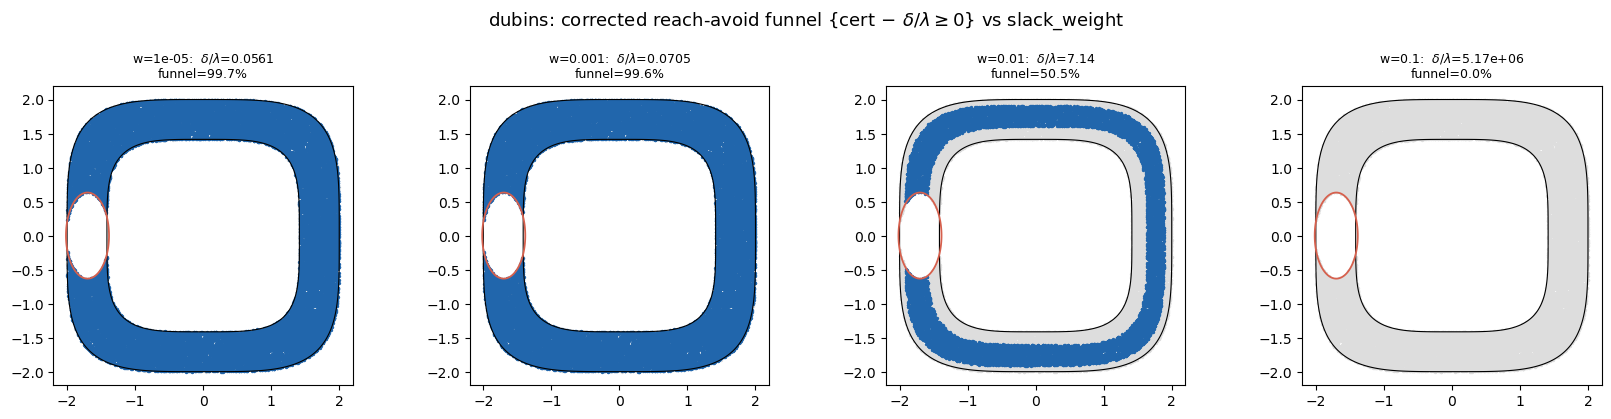

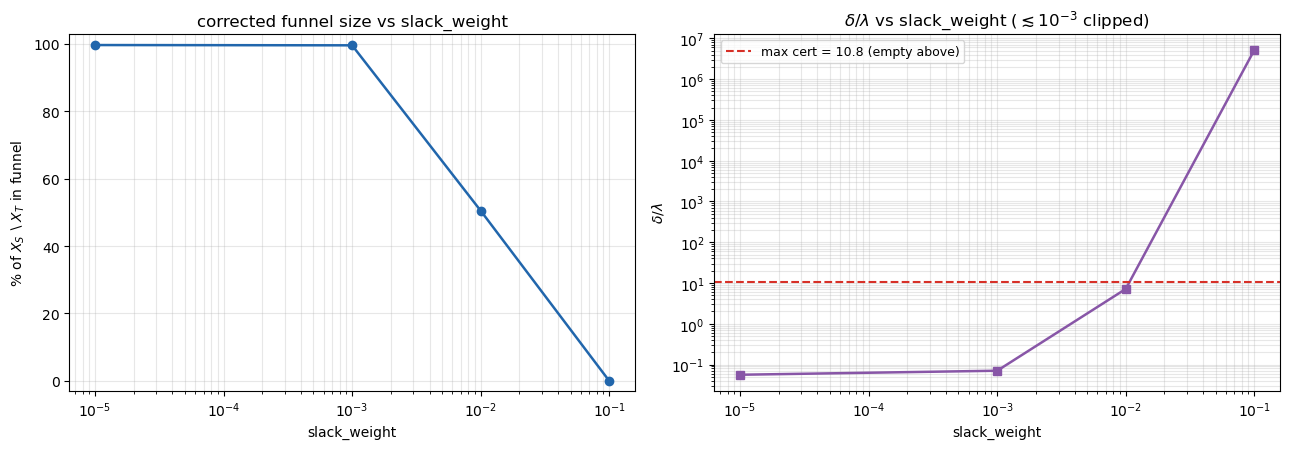


FINAL per-weight table (for the downstream manual selection):
 slack_weight  delta_over_lambda  funnel_pct  u_max_eff_omega  u_max_eff_a  n_kept
      0.00001       5.612311e-02   99.672340              7.9          5.1     187
      0.00100       7.045099e-02   99.592631              7.9          5.1     187
      0.01000       7.139100e+00   50.509993              7.9          5.1     187
      0.10000       5.174933e+06    0.000000              7.8          5.1     186


In [18]:
sub = _rng.choice(Yin.shape[1], size=min(25_000, Yin.shape[1]), replace=False)
ncol = 4
nrow = int(np.ceil(len(df_summary) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 4.0 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, (_, r) in zip(axes, df_summary.iterrows()):
    tau = float(r["delta_over_lambda"])
    inside = (cert_in[sub] - tau) >= 0
    frac = 100.0 * float(np.mean((cert_in - tau) >= 0))
    ax.scatter(Yin[0, sub][~inside], Yin[1, sub][~inside], s=2, c="#dddddd")
    ax.scatter(Yin[0, sub][inside], Yin[1, sub][inside], s=2, c="#2166ac")
    ax.contour(G1, G2, Zc, levels=[0], colors="k", linewidths=0.8)
    ax.contour(G1, G2, Zt, levels=[0], colors="#d6604d", linewidths=1.3)
    ax.set_aspect("equal")
    ax.set_xlim(LO, HI)
    ax.set_ylim(LO, HI)
    ax.set_title(
        f"w={r['slack_weight']:g}:  "
        + r"$\delta/\lambda$="
        + f"{tau:.3g}\nfunnel={frac:.1f}%",
        fontsize=9,
    )
for ax in axes[len(df_summary) :]:
    ax.axis("off")
fig.suptitle(
    r"dubins: corrected reach-avoid funnel $\{$cert$\,-\,\delta/\lambda\geq0\}$ vs slack_weight",
    y=1.005,
    fontsize=13,
)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "funnel_byweight_dubins.png"), dpi=120, bbox_inches="tight"
)
plt.show()

# funnel% and delta/lambda vs slack_weight
ws = np.array(sorted(df_summary["slack_weight"].values))
g = df_summary.set_index("slack_weight").loc[ws]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))
axL.semilogx(ws, g["funnel_pct"].values, "o-", color="#2166ac", lw=1.8)
axL.set_xlabel("slack_weight")
axL.set_ylabel(r"% of $X_S\setminus X_T$ in funnel")
axL.set_ylim(-3, 103)
axL.grid(True, which="both", alpha=0.3)
axL.set_title("corrected funnel size vs slack_weight")
axR.loglog(
    ws,
    np.clip(g["delta_over_lambda"].values, 1e-3, None),
    "s-",
    color="#8856a7",
    lw=1.8,
)
axR.axhline(
    cert_max,
    color="#d73027",
    ls="--",
    lw=1.5,
    label=f"max cert = {cert_max:.3g} (empty above)",
)
axR.set_xlabel("slack_weight")
axR.set_ylabel(r"$\delta/\lambda$")
axR.grid(True, which="both", alpha=0.3)
axR.legend(fontsize=9)
axR.set_title(r"$\delta/\lambda$ vs slack_weight ($\lesssim10^{-3}$ clipped)")
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "funnel_curves_byweight_dubins.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

print("\nFINAL per-weight table (for the downstream manual selection):")
print(
    df_summary[
        [
            "slack_weight",
            "delta_over_lambda",
            "funnel_pct",
            "u_max_eff_omega",
            "u_max_eff_a",
            "n_kept",
        ]
    ].to_string(index=False)
)